# 1. Что у нас есть в датасете

Создадим `2_ids.csv` с содержимым
```
mcd,sid,mct
20230810,ANX726,1630
20230405,AAN112,1635
```
Скачаем сабсет с данными
```
python3 download.py --output /path/to/datasets/ava-256 --captures-file 2_ids.csv -n 2
```
Получим около 23Gb

Нас интересует только `decoder` папка

* `images/<camera_id>.zip/*/<image_id>.avif` - 80 камер, ~10000 картинок для камеры
* `segmentation_parts/<camera_id>.zip/*/<image_id>.png` - та же структура, 2D сегментационные маски. Есть бекграунд, кожа, волосы, губы, зубы, язык, очки, одежда, бровей нет
* `keypoints_3d/keypoints_3d.zip/<image_id>.npy` - 3D кейпойнты с шейпом [160, 6]. Они camera-agnostic т.к. 3D
* `uv_image/color.zip/*/<image_id>.avif` - картинки в UV координатах, тоже от камеры не зависят
* `kinematic_tracking/registration_vertices.zip/<image_id>.ply` - как я понял, это нужно чтобы перевести UV координаты в 3D координаты для картинки
* `head_pose/head_pose.zip/<image_id>.txt` - 3x4 матрицы, вместе с `camera_calibration.json` по идее должен быть способ перевести 3D координаты в 2D для каждой камеры и картинки

# 2. Какие подходы вообще можно использовать?

### Бейзлайн через существующую разметку 3D кейпойнтов

Так как в разметке кейпойнтов есть брови, напрашивается вариант относительно простого бейзлайна получить 
сегментационные маски из них.

Сразу возникает много нюансов в том как это можно реализовать

1. Кусочно-линейно интерполировать точки в 3D, получить много промежуточных точек, дальше перевести их в 2D с помощью `head_pose` и `camera_calibration`. Проблема в том что точек всего 18 на обе брови, а это значит что вероятно маски будут неточными, угловатыми или заползать на другие части тела. Можно вместо кусочно-линейной интерполяции попробовать соединить 3D точки сплайном. Либо же соединять их 2D сплайнами уже после проекции на каждой конкретной картинке. 
2. Независимо от того как мы получим 2D точки, нам нужно будет добавить какой-то постпроцессинг: 
   - сглаживание углов, например через erosion + dilation (может и не нужно)
   - обрезание при наложении на другие маски (волосы, бэкграунд)
   
Возможные проблемы при таком подходе:
1. Я предположил что нам скорее всего важна консистентность итоговых масок между камерами. Консистентность мы не сохраним, особенно если мы соединяем точки в 2D пространствах независимо и/или потом жестко постпроцессим
2. Мелкие детали неизбежно потеряются, т.к. кейпойнты это все-таки очень lossy формат по сравнению с сегментационной маской. Как я понял, нам не важна субпиксельная точность, но детали вроде выпирающих волосков или неровной границы брови терять не хочется
3. На картинках богатая мимика. Что если бровь где-то выгибается в кривую с несколькими точками перегиба? Тогда кейпойты вообще это не покажут и маска будут неправильной
4. Как соединять точки если у кого-то монобровь? Даже если у наших двух людей не монобровь, для хорошей работы нашего решения в продакшне нужно предусмотреть такую возможность. То есть пришлось бы искать такие кейсы и проверять на них отдельно.

Если реализовывать что-то одно, то хотелось бы найти метод получше чем этот

   

### Разметка через foundation модели в UV координатах

Можно использовать, например, SAM2 или SAM3. Последний удобен тем что можно задавать текстовые промпты. 
Гипотеза в том что брови UV-представлениях хорошо различимы, и модели могут справиться с их нахождением. 
Можно запромптить модели:
- текстовым описанием типа `eyebrow`
- несколькими ключевыми точками засемпленными изнутри выпуклой оболочки 3D точек (для этого их нужно тоже перевести в UV)
    
Таким образом мы получим маски в UV пространстве, которые потом можно попробовать перевести в 2D для каждой камеры и позы. Есть шанс что удастся задетектить мелкие детали + сохранится консистентность между камерами. Возможно, понадобится в конце обрезать при наложении на другие маски. 

Детектить брови на UV должно быть удобнее чем на 2D картинках для каждой camera_id отдельно, не только из-за консистентности, но и из-за экономии компьюта в 80 раз

UPD: Когда наконец удалось побороть геометрию UV<->3D<->2D преобразований и реализовать этот подход, в нем вскрылась другая проблема. По всей видимости, в 3D mesh волосы на бровях не имеют своих полигонов, поэтому когда камера смотрит снизу вверх брови выпирают за пределы маски (см раздел 6). Что еще хуже, при таких углах маска заползает на нос, а масок носа в разметке нет. Как выяснилось впоследствии, SAM3 тоже не может нормально сегментировать нос на UV картинках. Можно восстановить маски носа из кейпойнтов и обрезать по ним - но тут риск больших неточностей.

Еще одна проблема: оказалось неочевидно как обрезать маску бровей при наложении ее на маску волос. Если камера смотрит снизу вверх, брови видны поверх волос и обрезать не надо. Если камера смотрит сверху вниз, то волосы как правило достаточно длинные чтобы загораживать брови => обрезать надо. Если камера смотрит с затылка, бровей вообще не видно. Учитывать все это очень сложно и непрактично.

В итоге я пришел к выводу что практичнее размечать 2D картинки напрямую

### Разметка через foundation модели для каждой 2D картинки напрямую

Теперь качество сегментации значительно лучше, плюс не нужно беспокоиться о наложении на волосы/глаза/очки. Если маска бровей, полученная таким способом, перекрывает любую другую маску из разметки, достаточно поставить выше приоритет для маски бровей. Результаты см в секции 7

Минусы:
- консистентность между камерами больше не гарантируется. Насколько это критично, зависит от задачи для которой мы делаем разметку
- разметка теперь занимает приличное время, на моем лептопе с RTX 2070 3.5-4 секунды на картинку, картинок в 80 раз больше чем для UV координат

Тем не менее этот метод я решил вынести в демо скрипт `eyebrow_visualize.py` который для подмножества фреймов и камер рисует маски бровей поверх 2D картинок. Получаются детальные маски, устойчивые к поворотам камеры, не ломаются от окклюжнов прядями волос.

Установка зависимостей:

```
pip install -r requirements_eyebrow.txt
```

Перед запуском скрипта нужно руками поменять адрес скачанного датасета и адрес репозитория SAM3. Запускать так:

```
python3 eyebrow_visualize.py --out-dir <where/to/store/overlays/> --camera-id-subsample <n_cameras> --frame-id-subsample <n_frames>
```


### Дальнейшие направления исследований

1. Проверить на всякий случай подход с восстановлением точек из 3D кейпойнтов (но я не верю что это будет лучше работать)
2. Насобирать краевых случаев и понять есть ли ситуации где SAM3 работает плохо, и можем ли мы как-то улучшить их эвристиками
3. Подумать над синхронизацией масок с разных камер, если это важно для наших downstream tasks
4. Попробовать убыстрить инференс. Я уже попробовал EfficientSAM3 (легкие дистиллированные модели), они работают намного хуже, включать в анализ не стал

# 3. Минимальный EDA

In [ ]:
!pip install -r requirements.txt

In [1]:
import io
import pickle
import json
import os

from random import sample

import numpy as np
import matplotlib.pyplot as plt
import pillow_avif

from PIL import Image
from zipp import Path as ZipPath
from mpl_toolkits.mplot3d import axes3d, Axes3D 
from plyfile import PlyData

import sys
sys.path.append('./demos/keypoints.py')
sys.path.append('./demos/mesh.py')
sys.path.append('./demos/segmentation.py')

import demos.keypoints, demos.mesh, demos.segmentation
from utils import load_camera_calibration


### Image sample

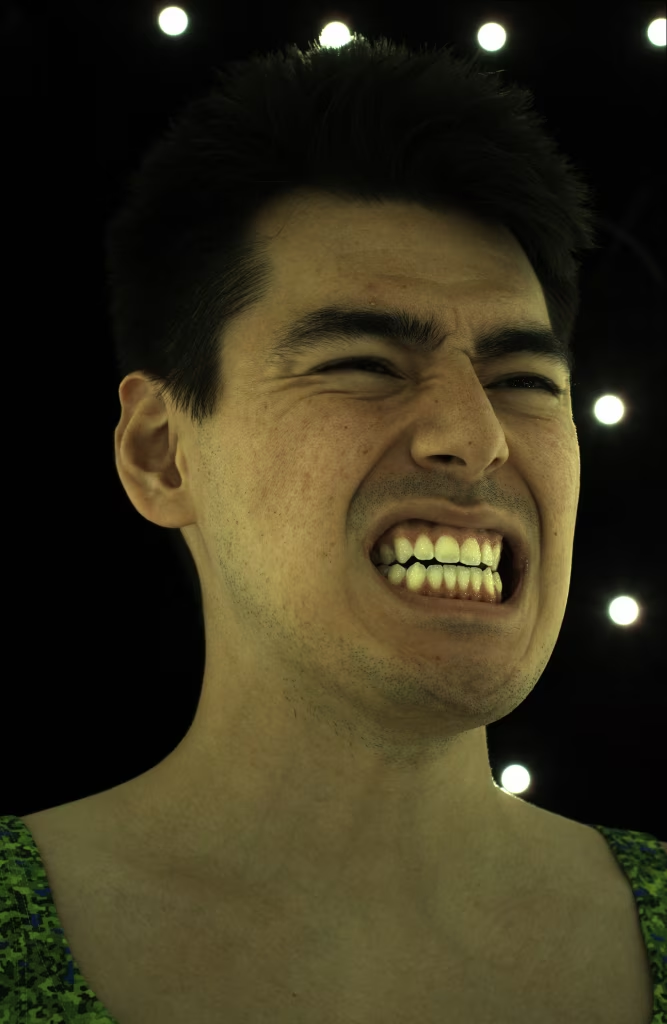

In [11]:
ava_dir = "/home/kirillfish/Datasets/ava-256"

# camera_id = '400939'
# frame_id = 140900
# subject_id = "20230405--1635--AAN112"

camera_id = '401452'
frame_id = 128450
subject_id = "20230810--1630--ANX726"

base_dir = f"{ava_dir}/{subject_id}/decoder/"
path = ZipPath(
                base_dir + "image/" + f"cam{camera_id}.zip",
                f"cam{camera_id}/{int(frame_id):06d}.avif",
            )
img_bytes = path.read_bytes()
image = Image.open(io.BytesIO(img_bytes))
display(image)

### Keypoints Projected on Image


Loaded camera calibration
Loaded keypoints of shape (273, 6)


<module 'matplotlib.pyplot' from '/home/kirillfish/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>

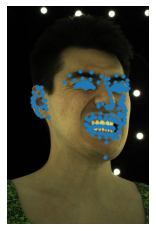

In [4]:
demos.keypoints.plot_keypoints_on_image(ava_dir, subject_id, base_dir, camera_id, frame_id)

In [5]:
keypoint_raw_path = ZipPath(
                base_dir + "keypoints_3d/" + f"keypoints_3d.zip",
                f"{int(frame_id):06d}.npy",
            )
kps_bytes = keypoint_raw_path.read_bytes()
kps = np.load(io.BytesIO(kps_bytes))
kps.shape

(273, 6)

In [6]:
path = f"{base_dir}/camera_calibration.json"
camera_calibration = load_camera_calibration(path)
params = camera_calibration[camera_id]
params

{'intrin': array([[1.00941222e+04, 0.00000000e+00, 1.78126152e+03],
        [0.00000000e+00, 1.00900679e+04, 1.78694174e+03],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]),
 'extrin': array([[ 9.22008960e-01, -1.08431196e-01, -3.71674796e-01,
          3.79729285e+02],
        [ 8.89934268e-02,  9.93631438e-01, -6.91139372e-02,
          8.16813818e+01],
        [ 3.76801869e-01,  3.06470556e-02,  9.25786752e-01,
          1.02164333e+02]]),
 'dist': array([-0.07552279, -0.00032872, -0.00607074,  0.00496359,  0.        ]),
 'model': 'radial-tangential',
 'height': 4096,
 'width': 2668}

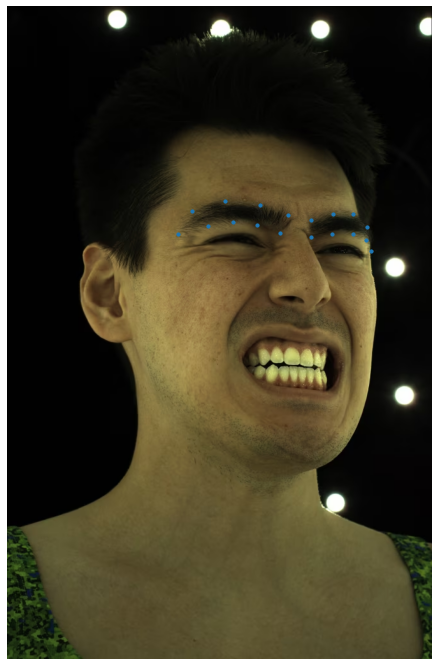

In [7]:
def plot_eybrows_on_image(image, keypoints, params, showfig=False):
    """
    Перебором определяем что за брови отвечают точки с 8 по 25
    """

    intrin = params["intrin"]
    extrin = params["extrin"]
    
    if keypoints.shape[0] > 18:
        keypoints = keypoints[8:26, :]
    keypoints = keypoints.reshape(-1, 6)

    keypoints = np.append(keypoints[:, 1:4], np.ones((keypoints.shape[0], 1)), axis=1)

    twod = np.dot(np.matmul(intrin, extrin), np.transpose(keypoints))
    twod /= twod[-1]
    twod /= 4  # images have been downscaled by 4
    
    fig, ax = plt.subplots()
    fig.set_figheight(12)
    fig.set_figwidth(8)
    fig.patch.set_visible(False)
    ax.axis("off")

    plt.imshow(image)
    plt.scatter([twod[0]], [twod[1]], s=10)

    plt.box(False)

    if showfig:
        plt.show()


plot_eybrows_on_image(image, kps, params, True)

# 4. Учимся проецировать 3D keypoints на UV координаты

In [78]:
camera_id = '401452'
frame_id = 128450
subject_id = "20230810--1630--ANX726"
base_dir = f"./dataset/{subject_id}/decoder/"

from eyebrow_utils import (
    load_keypoints_3d,
    get_eyebrow_keypoints,
    keypoints_3d_to_uv,
    project_uv_to_2d,
    load_head_pose,
    project_segmentation_from_uv
)
from utils import load_camera_calibration, load_obj


def get_verts(base_dir, frame_id, head_pose):
    # load per-frame registered mesh (head-local)
    path = ZipPath(
        f"{base_dir}/kinematic_tracking/registration_vertices.zip",
        f"{frame_id:06d}.ply",
    )
    verts = np.array([list(v) for v in PlyData.read(io.BytesIO(path.read_bytes()))["vertex"].data])

    # pose to world
    verts_h = np.hstack([verts, np.ones((verts.shape[0], 1))])
    verts_world = (head_pose @ verts_h.T).T
    return verts_world


camera_params = load_camera_calibration(f"{base_dir}/camera_calibration.json")[camera_id]
# use topology + UVs from face_topology, but vertices from registration
mesh = load_obj("assets/face_topology.obj")

keypoints = load_keypoints_3d(base_dir, frame_id)
eyebrow_kpts = get_eyebrow_keypoints(keypoints)
head_pose = load_head_pose(base_dir, frame_id)
verts_world = get_verts(base_dir, frame_id)

uv_coords = keypoints_3d_to_uv(
    eyebrow_kpts[:, 1:4],
    verts_world, mesh["vi"], mesh["vt"], mesh["vti"],
)

# project without head_pose (already in world)
points_2d = project_uv_to_2d(
    uv_coords,
    verts_world, mesh["vi"], mesh["vt"], mesh["vti"],
    camera_params, head_pose=None,
)

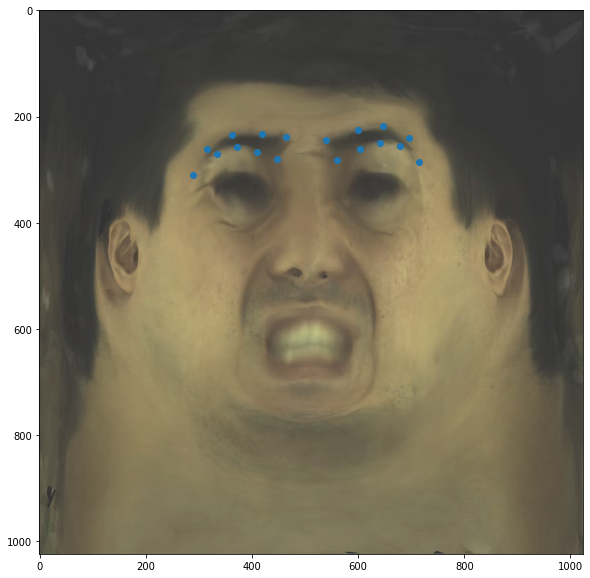

In [9]:
uv_path = ZipPath(
                base_dir + "uv_image/" + f"color.zip",
                f"color/{int(frame_id):06d}.avif",
            )
uv_bytes = uv_path.read_bytes()
uv = Image.open(io.BytesIO(uv_bytes))

plt.figure(figsize=(10,10))
plt.imshow(np.array(uv), alpha=0.8)
W, H = 1024, 1024
u = uv_coords[:, 0] * W
v = (1.0 - uv_coords[:, 1]) * H
plt.scatter(u, v)
plt.show()

# 5. Инициализация SAM3 и использование его для текстовых промптов в UV пространстве (ббоксами и точками промптить пока не будем)

In [18]:
sam3_root = '/home/kirillfish/Projects/sam3'
sys.path.append(sam3_root)
import sam3
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

model = build_sam3_image_model(
    bpe_path=os.path.join(sam3_root, 'sam3/assets/bpe_simple_vocab_16e6.txt.gz'),
    checkpoint_path=os.path.join(sam3_root, 'sam3.pt'),
    load_from_HF=False,
    enable_inst_interactivity=False,
)

processor = Sam3Processor(model, confidence_threshold=0.5)


In [180]:
def get_random_frame_ids(subject_id, num=5):
    base_dir = f"{ava_dir}/{subject_id}/decoder/"
    frame_ids_file = f'{base_dir}/frame_list.csv'
    all_frame_ids = []
    with open(frame_ids_file) as f:
        for i, line in enumerate(f):
            if i == 0:
                continue
            all_frame_ids.append(line.strip().split(',')[1])

    frame_ids = sample(all_frame_ids, num)
    return base_dir, frame_ids

found 1 object(s)
found 1 object(s)
found 1 object(s)
found 1 object(s)
found 1 object(s)


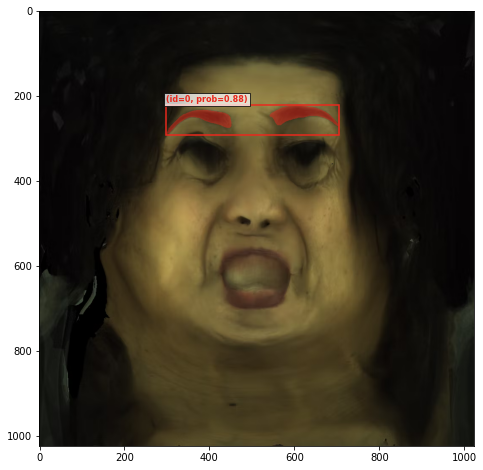

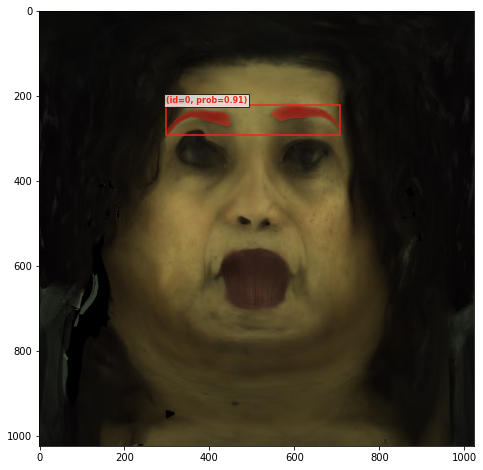

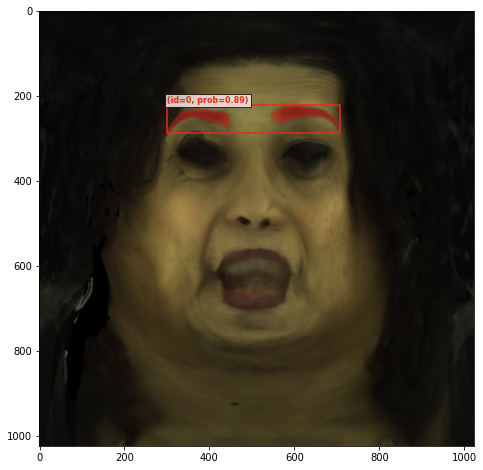

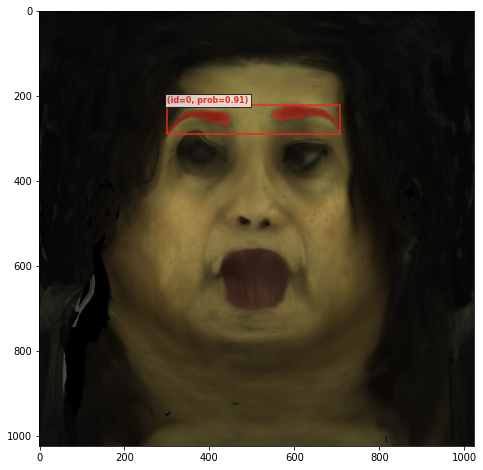

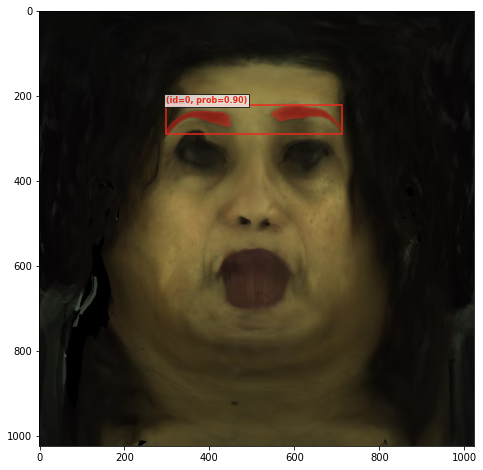

In [106]:
subject_id = "20230405--1635--AAN112"
base_dir, frame_ids = get_random_frame_ids(subject_id)

for frame_id in frame_ids:
    uv_path = ZipPath(
                    base_dir + "uv_image/" + f"color.zip",
                    f"color/{int(frame_id):06d}.avif",
                )
    uv_bytes = uv_path.read_bytes()
    image = Image.open(io.BytesIO(uv_bytes))
    
    width, height = image.size
    
    inference_state = processor.set_image(image)
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt="eyebrow")
    plot_results(image, inference_state)

found 1 object(s)
found 1 object(s)
found 1 object(s)
found 1 object(s)
found 1 object(s)


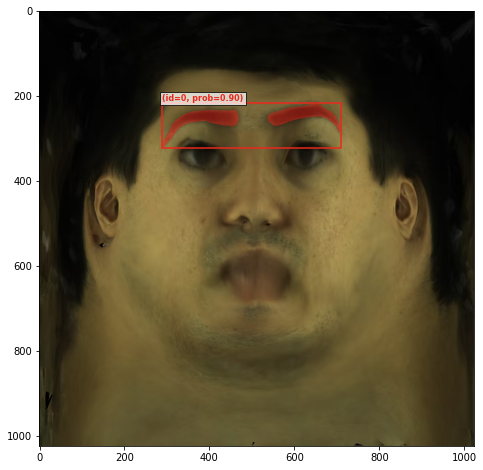

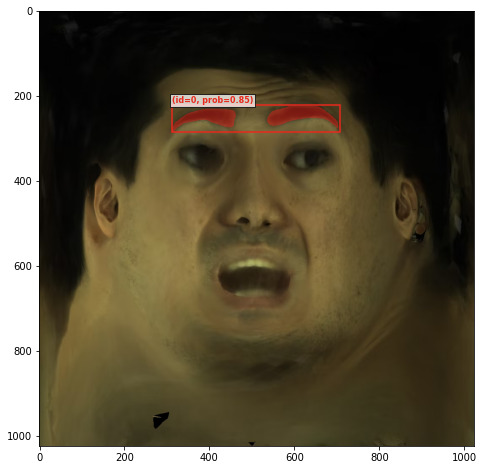

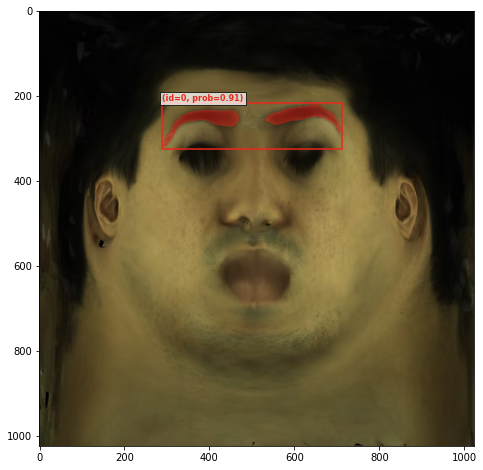

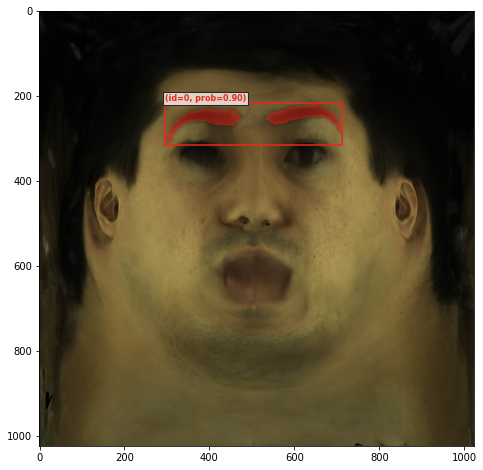

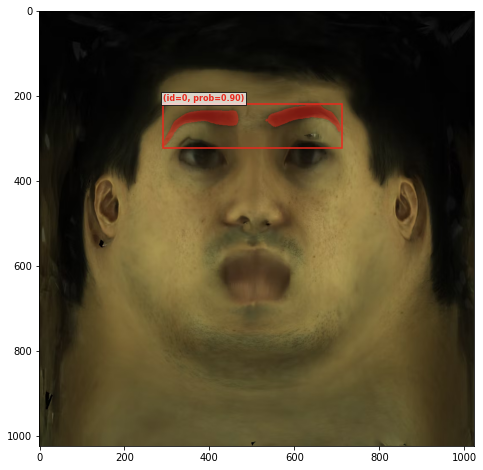

In [138]:
subject_id = "20230810--1630--ANX726"
base_dir, frame_ids = get_random_frame_ids(subject_id)

for frame_id in frame_ids:
    uv_path = ZipPath(
                    base_dir + "uv_image/" + f"color.zip",
                    f"color/{int(frame_id):06d}.avif",
                )
    uv_bytes = uv_path.read_bytes()
    image = Image.open(io.BytesIO(uv_bytes))
    
    width, height = image.size
    
    inference_state = processor.set_image(image)
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt="eyebrow")
    plot_results(image, inference_state)
#     НОСЫ НЕ ДЕТЕКТИТ
#     processor.set_confidence_threshold(0.1)
#     inference_state_nose = processor.set_image(image)
#     processor.reset_all_prompts(inference_state_nose)
#     inference_state_nose = processor.set_text_prompt(state=inference_state_nose, prompt="nose")
#     plot_results(image, inference_state_nose)

# 6. Проецируем SAM3 маски из UV в 2D пространство для соответствующего `image_id` и произвольного `camera_id`

In [114]:
keypoints = load_keypoints_3d(base_dir, int(frame_id))
eyebrow_kpts = get_eyebrow_keypoints(keypoints)
head_pose = load_head_pose(base_dir, int(frame_id))
verts_world = get_verts(base_dir, int(frame_id))

camera_id = '400939'
camera_params = load_camera_calibration(f"{base_dir}/camera_calibration.json")[camera_id]


mask_2d = project_segmentation_from_uv(
    inference_state['masks'].cpu().numpy()[0, 0, :, :],
    verts_world, mesh["vi"], mesh["vt"], mesh["vti"],
    camera_params,
    head_pose=None,
    output_size=(1024, 667)
)


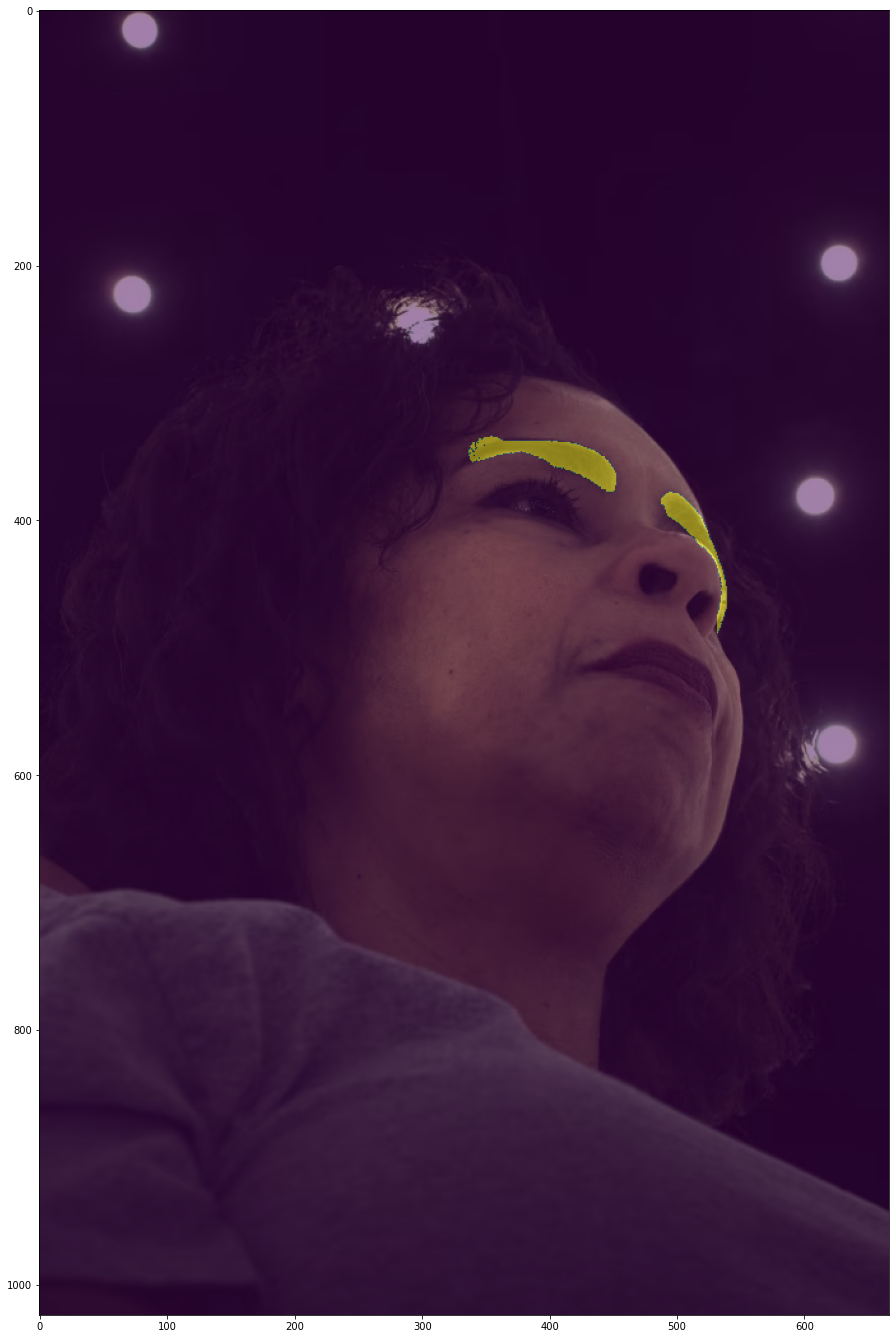

In [109]:
path = ZipPath(
                base_dir + "image/" + f"cam{camera_id}.zip",
                f"cam{camera_id}/{int(frame_id):06d}.avif",
            )
img_bytes = path.read_bytes()
image = Image.open(io.BytesIO(img_bytes))
plt.figure(figsize=(16, 24))
plt.imshow(np.array(image))
plt.imshow(mask_2d, alpha=0.5)
plt.show()

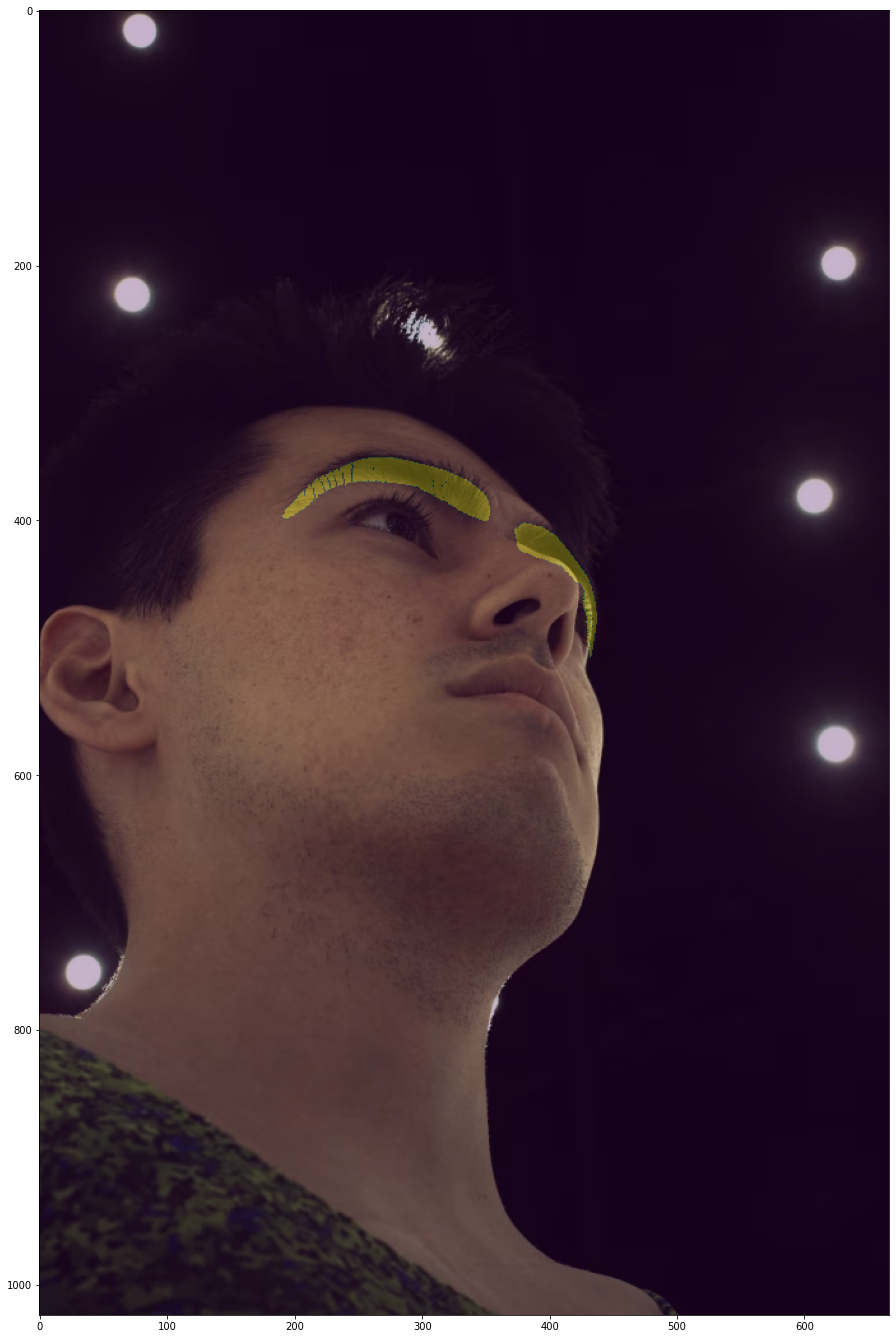

In [139]:
path = ZipPath(
                base_dir + "image/" + f"cam{camera_id}.zip",
                f"cam{camera_id}/{int(frame_id):06d}.avif",
            )
img_bytes = path.read_bytes()
image = Image.open(io.BytesIO(img_bytes))
plt.figure(figsize=(16, 24))
plt.imshow(np.array(image))
plt.imshow(mask_2d, alpha=0.3)
plt.show()

Получилось неидеально: по всей видимости, в 3D mesh волосы на бровях не добавляют выпуклости, поэтому при крутых углах камеры (как на представленном изображении, снизу вверх) брови выпирают за пределы маски. Что еще хуже, при таких углах маска заползает на нос. Как выяснилось впоследствии, SAM3 не может нормально сегментировать нос на UV картинках. Выхода два:
1. Вытащить маски носа из кейпойнтов и обрезать
2. Попробовать все-таки SAM3 на отдельных 2D картинках

# 7. Сравниваем с SAM3 масками, полученными для 2D картинки напрямую

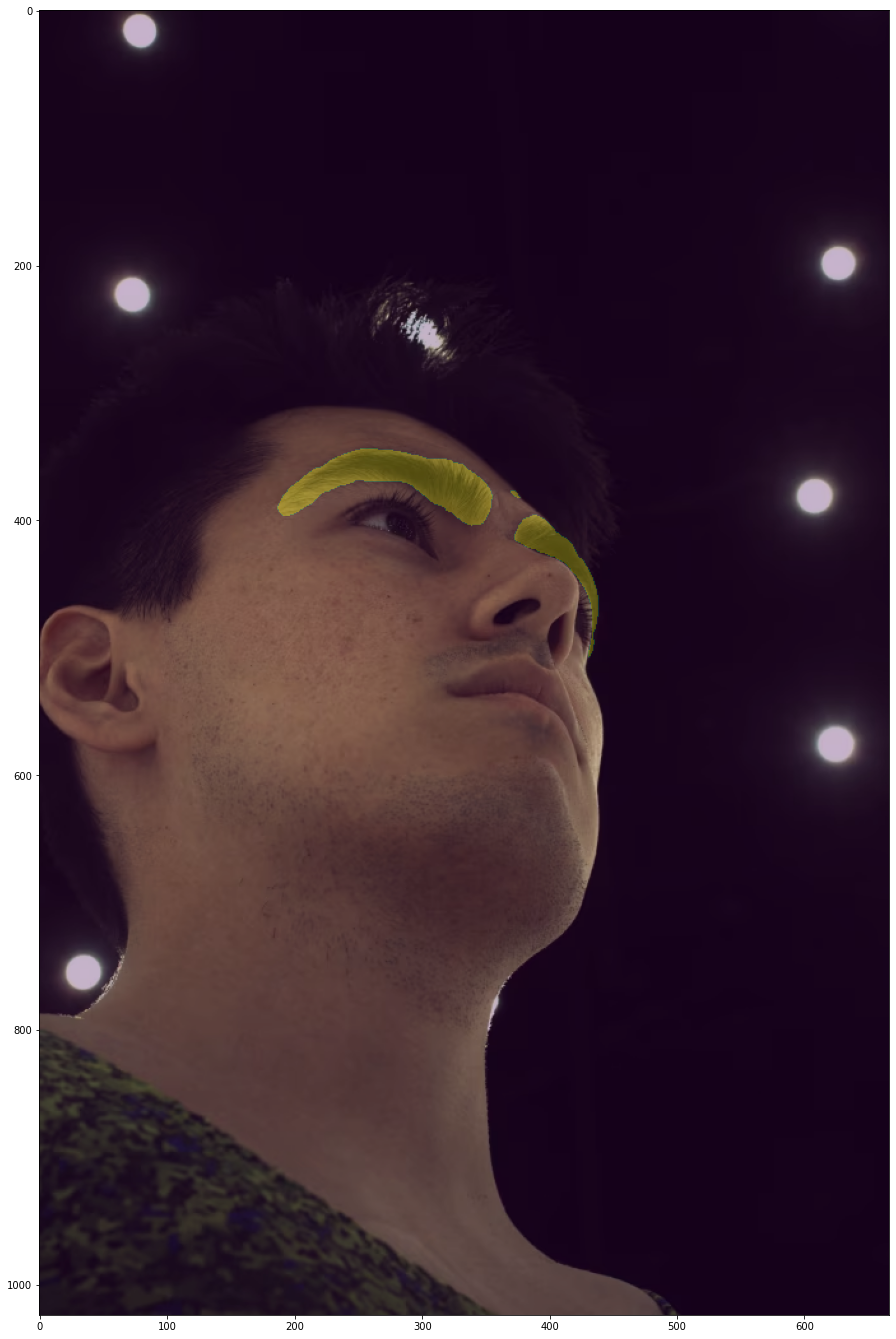

In [142]:
inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="eyebrow")
masks_2d_direct = inference_state['masks'].cpu().numpy()[0, 0, :, :]
plt.figure(figsize=(16, 24))
plt.imshow(np.array(image))
plt.imshow(masks_2d_direct, alpha=0.3)
plt.show()
#plot_results(image, inference_state)   

Намного лучше, осталось лишь немного отфильтровать шумы. Обрезка по уже существующим в разметке сегментационным маскам в данном случае не нужна.

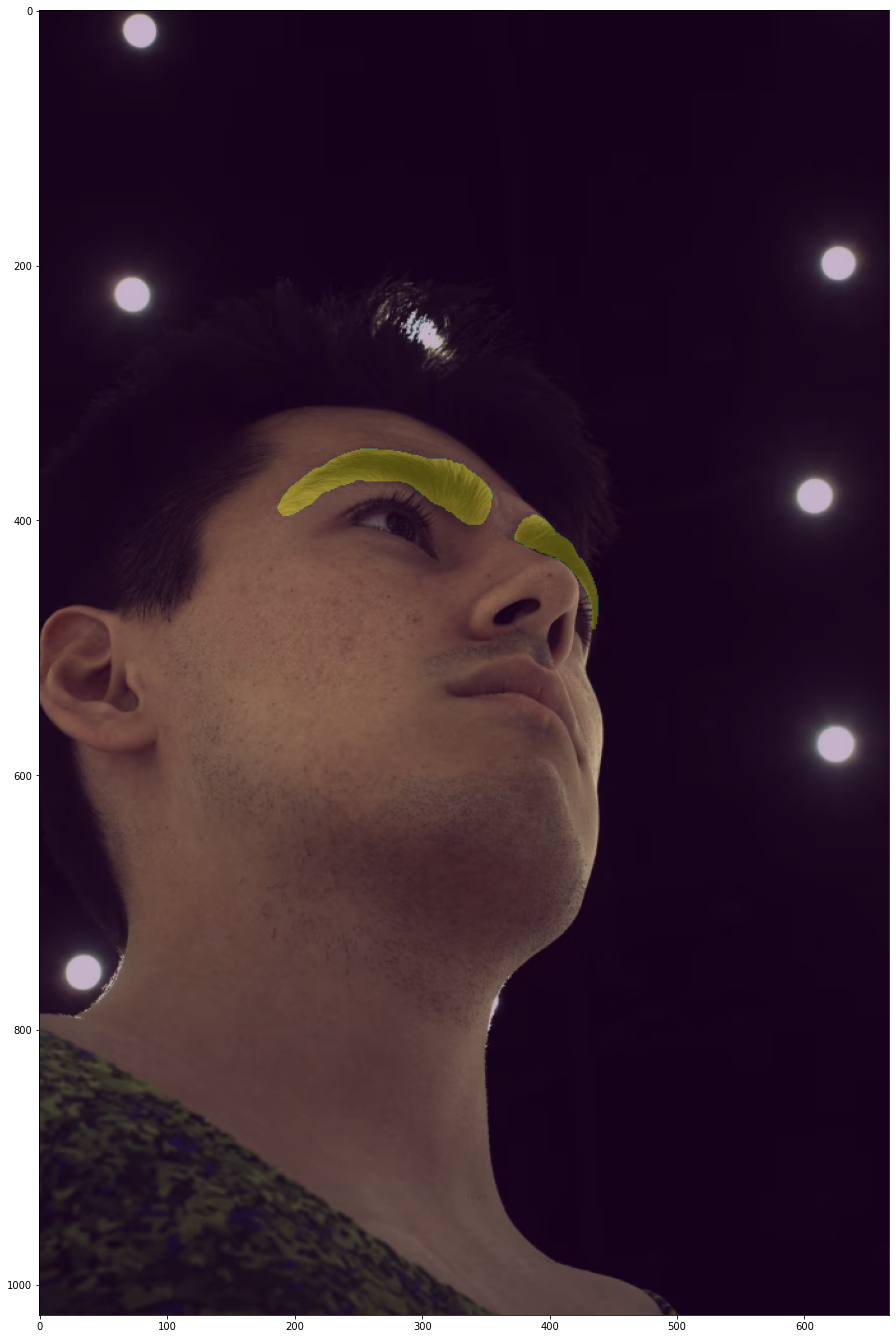

In [178]:
from cv2 import morphologyEx
import skimage

kernel = np.ones((3, 3),np.uint8)

opening = cv2.morphologyEx(masks_2d_direct.astype('uint8'), cv2.MORPH_OPEN, kernel)
area_filtered = skimage.morphology.area_opening(opening, area_threshold=500, connectivity=2)

plt.figure(figsize=(16, 24))
plt.imshow(np.array(image))
# plt.imshow(seg_gt_mask, alpha=0.3)
plt.imshow(area_filtered, alpha=0.3)
plt.show()

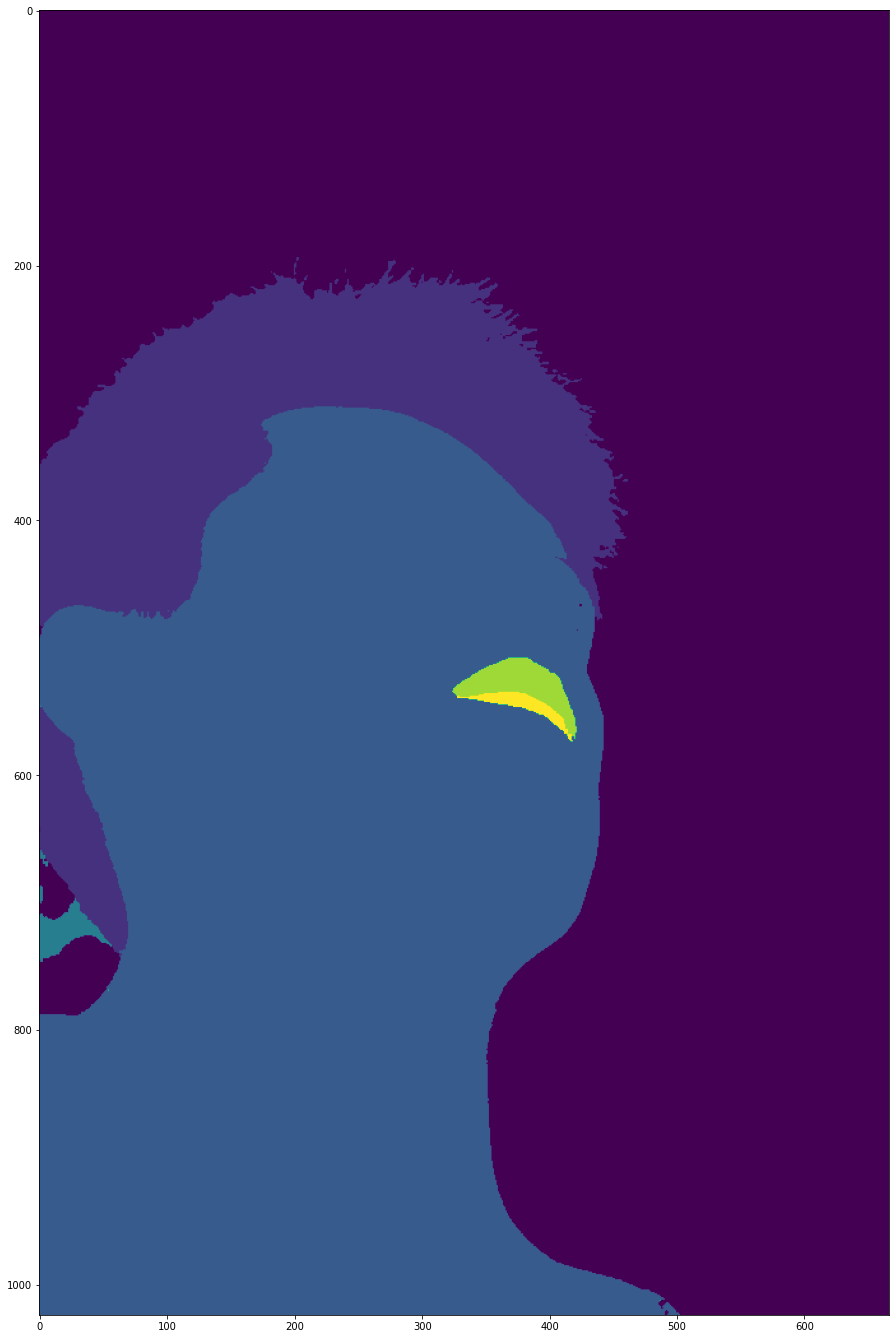

In [124]:
seg_path = ZipPath(
                base_dir + "segmentation_parts/" + f"cam{camera_id}.zip",
                f"cam{camera_id}/{int(frame_id):06d}.png",
            )
seg_bytes = seg_path.read_bytes()
seg_gt_mask = np.array(Image.open(io.BytesIO(seg_bytes)))
plt.figure(figsize=(16, 24))
plt.imshow(seg_gt_mask)
#plt.imshow(mask_2d, alpha=0.3)
plt.show()

### Таким образом, мы отбрасываем подход с сегментацией по UV и останавливаемся на сегментации по 2D